In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
current_dir = Path.cwd()
project_root = current_dir.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done!")

Done!


### Ok, let's do it via pytorch

In [12]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#### Transformation

In [4]:
transformation = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [6]:
train_dataset = datasets.MNIST(
    root=project_root / "data",
    train=True,
    transform=transformation,
    download=True
)

In [7]:
test_dataset = datasets.MNIST(
    root=project_root / "data",
    train=False,
    transform=transformation,
    download=True
)

In [8]:
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [10]:
for img, label in train_dataloader:
    print(f"Label: {label}, shape: {label.shape}")
    print(f"img: {img}, shape: {img.shape}")
    break

Label: tensor([3, 6, 3, 9, 1, 9, 6, 1, 4, 5, 0, 4, 5, 2, 9, 9, 3, 7, 6, 9, 8, 7, 6, 0,
        4, 2, 6, 7, 1, 7, 5, 8, 9, 9, 9, 3, 2, 9, 7, 6, 5, 3, 1, 3, 0, 8, 4, 8,
        5, 2, 1, 7, 6, 5, 3, 1, 8, 6, 6, 4, 4, 7, 5, 2, 9, 3, 6, 3, 8, 2, 1, 3,
        2, 6, 4, 2, 0, 1, 0, 1, 4, 2, 1, 7, 7, 7, 9, 4, 9, 9, 3, 7, 9, 7, 8, 5,
        0, 7, 3, 7, 7, 9, 0, 1, 6, 2, 9, 9, 0, 5, 8, 5, 5, 1, 9, 3, 4, 2, 5, 1,
        4, 0, 7, 7, 5, 8, 5, 7]), shape: torch.Size([128])
img: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), shape: torch.Size([128, 784])


### Let's Build the encoder

In [28]:
class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.layer1 = nn.Linear(784, 400)
        self.layer2 = nn.Linear(400, 100)
        self.mu_head = nn.Linear(100, latent_dim)
        self.log_var_head = nn.Linear(100, latent_dim)
        
    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        x = self.layer2(x)
        x = F.relu(x)
        mu = self.mu_head(x)
        log_var = self.log_var_head(x)
        return mu, log_var

### Reparametarization Trick

In [29]:
def reparametarization(mu, log_var):
    sigma = torch.exp(0.5 * log_var)
    epsilon = torch.randn_like(mu)
    return mu + sigma * epsilon

### Let's Build the Decoder

In [30]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.layer1 = nn.Linear(latent_dim, 100)
        self.layer2 = nn.Linear(100, 400)
        self.layer3 = nn.Linear(400, 784)
        
    def forward(self, z):
        z = self.layer1(z)
        z = F.relu(z)
        z = self.layer2(z)
        z = F.relu(z)
        z = self.layer3(z)
        x = torch.sigmoid(z)
        return x

### VAE neural network

In [31]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        
    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = reparametarization(mu=mu, log_var=log_var)
        x_constructed = self.decoder(z)
        return x_constructed, mu, log_var

### Loss Function

In [32]:
def vae_loss(x_constructed, x_original, mu, log_var):
    # reconstruction error
    recons_err = F.binary_cross_entropy(x_constructed, x_original, reduction='sum')
    # Kl divergence regularizer
    kl_loss = -0.5 * torch.sum(1 + log_var - mu**2 - torch.exp(log_var))
    loss = (recons_err + kl_loss)/x_original.size(0)
    return loss

### Training Loop

In [33]:
latent_dim = 2
num_epochs = 20
model = VAE(latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [36]:
for epoch in range(num_epochs):
    total_loss = 0
    for image, _ in train_dataloader:
        x_contructed, mu, log_var = model.forward(image)
        loss = vae_loss(x_contructed, image, mu, log_var)
        total_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    avg_loss = total_loss/len(train_dataloader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss.item():.2f}")

Epoch 1, Loss: 141.36
Epoch 2, Loss: 141.11
Epoch 3, Loss: 140.95
Epoch 4, Loss: 140.70
Epoch 5, Loss: 140.60
Epoch 6, Loss: 140.18
Epoch 7, Loss: 140.09
Epoch 8, Loss: 139.84
Epoch 9, Loss: 139.82
Epoch 10, Loss: 139.58
Epoch 11, Loss: 139.26
Epoch 12, Loss: 139.02
Epoch 13, Loss: 138.92
Epoch 14, Loss: 138.78
Epoch 15, Loss: 138.64
Epoch 16, Loss: 138.60
Epoch 17, Loss: 138.42
Epoch 18, Loss: 138.23
Epoch 19, Loss: 138.41
Epoch 20, Loss: 138.16


### Eval mode

In [41]:
with torch.no_grad():
    images, _ = next(iter(test_dataloader))
    x_contructed, mu, log_var = model(image)

In [42]:
image.shape

torch.Size([128, 784])

In [43]:
image = images[0].view(28, 28)
recon = x_contructed[0].view(28,28)

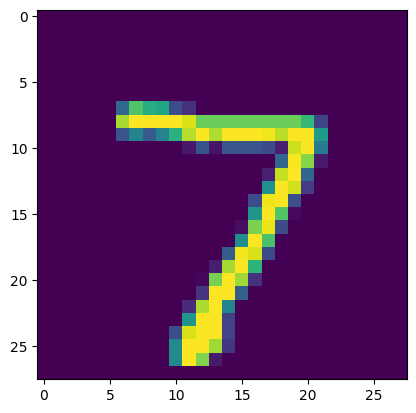

In [44]:
plt.imshow(image)

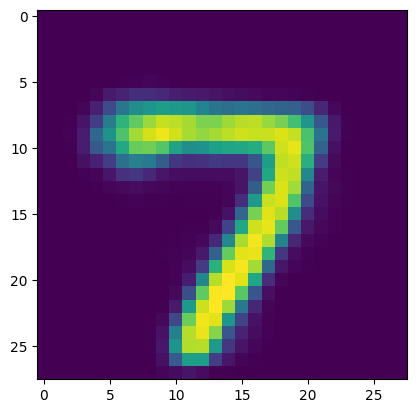

In [45]:
plt.imshow(recon)

### Generating new digits

In [46]:
with torch.no_grad():
    z = torch.randn(16, latent_dim)
    generated = model.decoder(z)

In [47]:
generated.shape

torch.Size([16, 784])

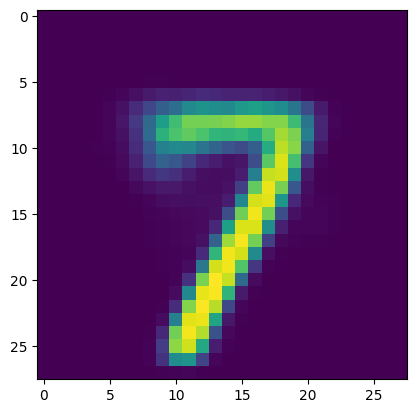

In [53]:
plt.imshow(generated[0].view(28,28))

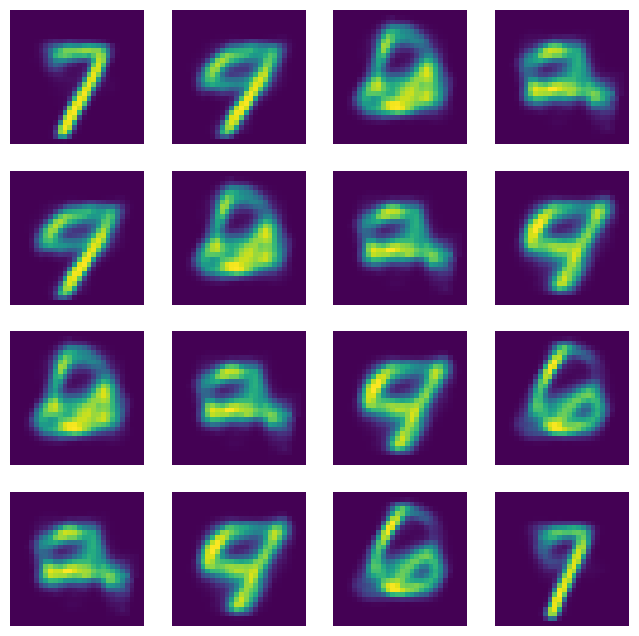

In [54]:
figs, axes = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    for j in range(4):
        axes[i][j].imshow(generated[i+j].view(28, 28))
        axes[i][j].axis('off')

In [55]:
all_mu = []
all_labels = []

with torch.no_grad():
    for images, labels in test_dataloader:
        mu, log_var = model.encoder(images)
        all_mu.append(mu)
        all_labels.append(labels)

In [59]:
all_mu = torch.cat(all_mu, dim=0)
all_labels = torch.cat(all_labels, dim=0)

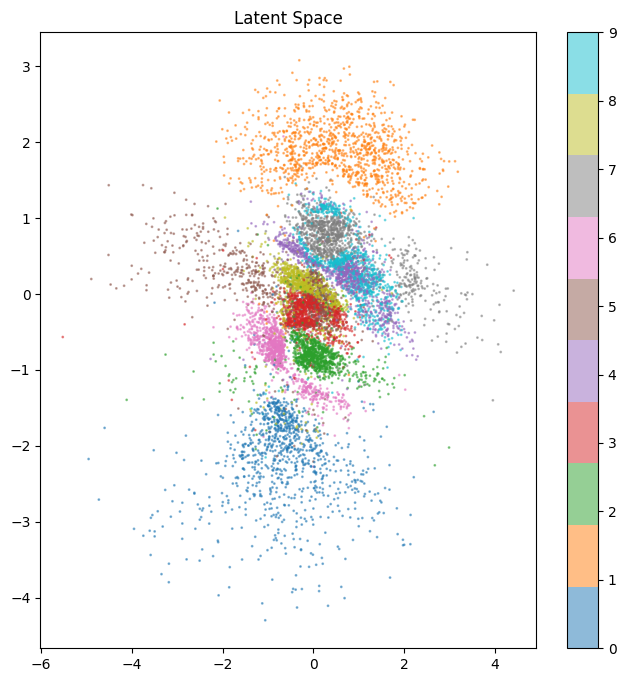

In [61]:
plt.figure(figsize=(8,8))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1],
                      c=all_labels,
                      cmap='tab10',
                      alpha=0.5,
                      s=1)
plt.colorbar(scatter)
plt.title("Latent Space")
plt.show()